In [1]:

# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')


In [2]:

# Loading the Dataset
data = pd.read_csv("student_habits_performance.csv")
print("Dataset Loaded Successfully")
print(data.head())


Dataset Loaded Successfully
  student_id  age  gender  study_hours_per_day  social_media_hours  \
0      S1000   23  Female                  0.0                 1.2   
1      S1001   20  Female                  6.9                 2.8   
2      S1002   21    Male                  1.4                 3.1   
3      S1003   23  Female                  1.0                 3.9   
4      S1004   19  Female                  5.0                 4.4   

   netflix_hours part_time_job  attendance_percentage  sleep_hours  \
0            1.1            No                   85.0          8.0   
1            2.3            No                   97.3          4.6   
2            1.3            No                   94.8          8.0   
3            1.0            No                   71.0          9.2   
4            0.5            No                   90.9          4.9   

  diet_quality  exercise_frequency parental_education_level internet_quality  \
0         Fair                   6                

In [3]:
#Check Missing Values
data.isna().sum()


student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

In [4]:
#Handle Missing Values
data = data.fillna(data.mean(numeric_only=True))


In [5]:
#Check Duplicates
data.duplicated().sum()


np.int64(0)

In [6]:
#Drop Duplicates
data = data.drop_duplicates()


In [7]:
#Check Data Types
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [8]:

# Preparing the Target Variable
def categorize_score(score):
    if score < 50:
        return "Low"
    elif score < 75:
        return "Average"
    else:
        return "High"

data["performance_category"] = data["exam_score"].apply(categorize_score)


In [9]:
 #Dropping unnecessary columns
data = data.drop(columns=["student_id", "exam_score"], errors="ignore")


In [10]:
# Encoding categorical columns
categorical_cols = data.select_dtypes(include=["object"]).columns
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])



In [11]:
# Defining features and target
X = data.drop("performance_category", axis=1)
y = data["performance_category"]

print("Features and target prepared successfully.")


Features and target prepared successfully.


In [12]:

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)


In [13]:

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [14]:

# Logistic Regression
log_model = LogisticRegression()
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)


In [15]:
print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Classification Report:\n", classification_report(y_test, y_pred_log))


Logistic Regression Results
Accuracy: 0.824
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.79      0.82       123
           1       0.80      0.87      0.83        94
           2       0.84      0.82      0.83        33

    accuracy                           0.82       250
   macro avg       0.83      0.83      0.83       250
weighted avg       0.83      0.82      0.82       250



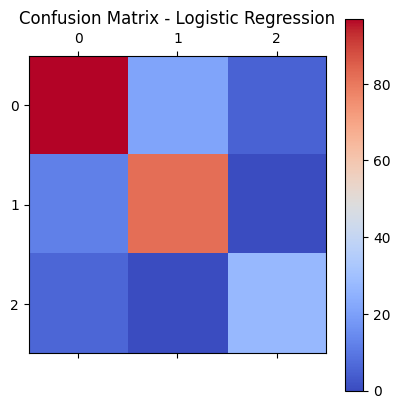

In [16]:
cm_log = confusion_matrix(y_test, y_pred_log)
plt.matshow(cm_log, cmap='coolwarm')
plt.title("Confusion Matrix - Logistic Regression")
plt.colorbar()
plt.show()


In [17]:

# Decision Tree Classifier
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)


In [18]:
print("Decision Tree Results")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Classification Report:\n", classification_report(y_test, y_pred_tree))


Decision Tree Results
Accuracy: 0.76
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.71      0.74       123
           1       0.80      0.86      0.83        94
           2       0.58      0.67      0.62        33

    accuracy                           0.76       250
   macro avg       0.72      0.75      0.73       250
weighted avg       0.76      0.76      0.76       250



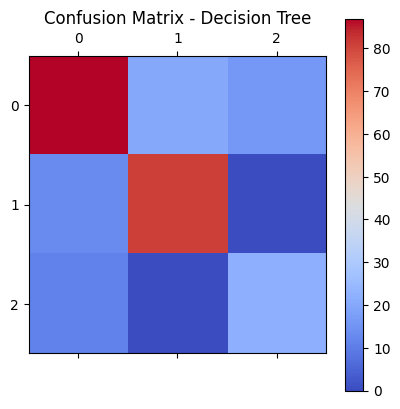

In [19]:
cm_tree = confusion_matrix(y_test, y_pred_tree)
plt.matshow(cm_tree, cmap='coolwarm')
plt.title("Confusion Matrix - Decision Tree")
plt.colorbar()
plt.show()


In [20]:

# Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)



In [21]:
print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))



Random Forest Results
Accuracy: 0.76
Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.80      0.77       123
           1       0.80      0.84      0.82        94
           2       0.75      0.36      0.49        33

    accuracy                           0.76       250
   macro avg       0.76      0.67      0.69       250
weighted avg       0.76      0.76      0.75       250



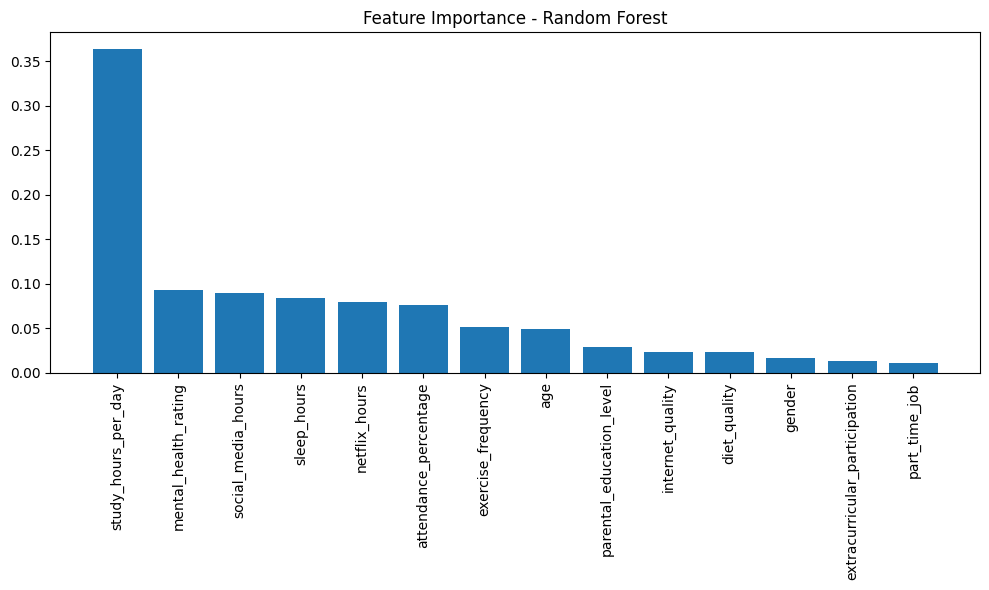

In [22]:
# Feature Importance Plot
importances = rf_model.feature_importances_
features = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), [features[i] for i in indices], rotation=90)
plt.title("Feature Importance - Random Forest")
plt.tight_layout()
plt.show()
